# Load Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn import metrics
from timeit import default_timer as timer
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
folder_path = '/content/drive/MyDrive/PENELITIAN PENGAJUAN BIMA/PELAKSANAAN PENELITIAN/Code Exponential Smoothing/'
file_list = os.listdir(folder_path)
file_list

['exponential_smoothing_model.pkl',
 'dataprediction_TES_Keputih.xlsx',
 'Hasil Ensemble.xlsx',
 'TES-KEPUTIH.ipynb',
 'TES-Gubeng.ipynb',
 'TES-KedungCowek.ipynb',
 'Plot Train and test.ipynb',
 'datatest_TES_Keputih.xlsx',
 'datatest_TES_Gubeng.xlsx',
 'datatest_TES_Cowek.xlsx',
 'dataprediction_TES_Gubeng.xlsx',
 'dataprediction_TES_Cowek.xlsx']

In [ ]:
train2 = pd.read_excel(folder_path+'dataprediction_TES_Keputih.xlsx')
train2.head()

,Tanggal,CH_Keputih,prediction,Rainfall_dummy,residual
0,2009-01-01,9.0,8.660418,1,0.339582
1,2009-01-02,0.0,4.092468,0,-4.092468
2,2009-01-03,6.0,1.886883,1,4.113117
3,2009-01-04,0.0,3.573985,0,-3.573985
4,2009-01-05,10.0,2.062801,1,7.937199


In [ ]:
test = pd.read_excel(folder_path+'datatest_TES_Keputih.xlsx')
test.head()

,Tanggal,CH_Keputih,prediction
0,2018-12-01,0,7.126569
1,2018-12-02,14,7.098496
2,2018-12-03,0,7.095689
3,2018-12-04,2,7.095408
4,2018-12-05,0,7.095380


In [ ]:
test['Rainfall_dummy'] = test['CH_Keputih'].apply(lambda x: 0 if x == 0 else 1)


In [ ]:
test['residual']= test['CH_Keputih']-test['prediction']
test.head()

,Tanggal,CH_Keputih,prediction,Rainfall_dummy,residual
0,2018-12-01,0,7.126569,0,-7.126569
1,2018-12-02,14,7.098496,1,6.901504
2,2018-12-03,0,7.095689,0,-7.095689
3,2018-12-04,2,7.095408,1,-5.095408
4,2018-12-05,0,7.095380,0,-7.095380


## Gabungan train and test

In [ ]:
data_series = pd.concat([train2,test],axis=0)
data_series

,Tanggal,CH_Keputih,prediction,Rainfall_dummy,residual
0,2009-01-01,9.0,8.660418,1,0.339582
1,2009-01-02,0.0,4.092468,0,-4.092468
2,2009-01-03,6.0,1.886883,1,4.113117
3,2009-01-04,0.0,3.573985,0,-3.573985
4,2009-01-05,10.0,2.062801,1,7.937199
...,...,...,...,...,...
26,2018-12-27,0.0,7.095377,0,-7.095377
27,2018-12-28,13.0,7.095377,1,5.904623
28,2018-12-29,2.0,7.095377,1,-5.095377
29,2018-12-30,0.0,7.095377,0,-7.095377


##Rolling mean

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


In [ ]:
rolling_mean_range = range(7, 15)  # Range from 7 to 14 days

rolling_means = []

for i in rolling_mean_range:
    rolling_mean = data_series.residual.rolling(window=i).mean()
    rolling_means.append(rolling_mean)

# Combine rolling means into a single DataFrame
rolling_mean_df = pd.concat(rolling_means, axis=1)
rolling_mean_df.columns = ['mean_' + str(i) for i in rolling_mean_range]

# Drop rows with NaN values
rolling_mean_df.dropna(inplace=True)

# Convert to a NumPy array
X = rolling_mean_df.values


In [ ]:
y = data_series.residual.iloc[rolling_mean_df.index + 1].values


In [ ]:
data_series['Rainfall_dummy'].iloc[13:,]

13    0
14    0
15    0
16    1
17    0
     ..
26    0
27    1
28    1
29    0
30    0
Name: Rainfall_dummy, Length: 3639, dtype: int64

In [ ]:
X2= pd.concat([pd.DataFrame(X),data_series['Rainfall_dummy'].iloc[13:,].reset_index()],axis=1)
X2

,0,1,2,3,4,5,6,7,index,Rainfall_dummy
0,6.104107,4.948573,3.796508,4.210577,3.502889,3.553742,2.965572,2.778001,13,0
1,3.489464,2.828587,2.165393,1.406852,2.000520,1.535978,1.734220,1.318028,14,0
2,-15.150226,1.615211,1.236015,0.798398,0.233087,0.875097,0.532860,0.788592,15,0
3,-7.022349,-11.452833,3.038956,2.555306,2.037536,1.416073,1.917698,1.525435,16,1
4,-4.009523,-7.726528,-11.586493,1.469483,1.172480,0.813093,0.333623,0.876736,17,0
...,...,...,...,...,...,...,...,...,...,...
3634,-5.666806,-5.095377,-4.873155,-5.095377,-5.277195,-5.428711,-5.556916,-4.666806,26,0
3635,-3.809663,-4.220377,-3.873155,-3.795377,-4.095377,-4.345377,-4.556916,-4.738234,27,1
3636,-3.523949,-3.970377,-4.317600,-3.995377,-3.913559,-4.178711,-4.403070,-4.595377,28,1
3637,-4.238234,-3.970377,-4.317600,-4.595377,-4.277195,-4.178711,-4.403070,-4.595377,29,0


In [ ]:
#X2=X2.drop(columns=['index'])
#X2.head()

##Solit data

In [ ]:
split_index = len(X) - 31  # Gunakan 31 data terakhir untuk pengujian (test).

X_train, X_test = X2[:split_index], X2[split_index:]  # Split input data X.
y_train, y_test = y[:split_index], y[split_index:]  # Split output data y.


##Build Neural Network

In [ ]:
model = Sequential([
    Dense(10, activation='relu', input_dim=X_train.shape[1]),  # Input layer
    Dense(15, activation='relu'),
    Dense(15, activation='relu'), # Hidden layer
    Dense(1)                                                          # Output layer
])


In [ ]:
model.compile(loss='mean_squared_error', optimizer='adam')


Epoch 1/100
91/91 [==============================] - 2s 4ms/step - loss: 17541.3145 - val_loss: 122.4778
Epoch 2/100
91/91 [==============================] - 0s 4ms/step - loss: 181.3747 - val_loss: 122.3854
Epoch 3/100
91/91 [==============================] - 0s 3ms/step - loss: 178.8697 - val_loss: 119.8971
Epoch 4/100
91/91 [==============================] - 0s 4ms/step - loss: 175.6089 - val_loss: 117.6465
Epoch 5/100
91/91 [==============================] - 0s 4ms/step - loss: 173.9630 - val_loss: 138.9867
Epoch 6/100
91/91 [==============================] - 0s 4ms/step - loss: 172.6682 - val_loss: 112.9674
Epoch 7/100
91/91 [==============================] - 0s 4ms/step - loss: 168.3236 - val_loss: 111.3461
Epoch 8/100
91/91 [==============================] - 0s 4ms/step - loss: 166.9708 - val_loss: 117.1301
Epoch 9/100
91/91 [==============================] - 0s 4ms/step - loss: 166.0648 - val_loss: 108.9689
Epoch 10/100
91/91 [==============================] - 0s 4ms/step - los

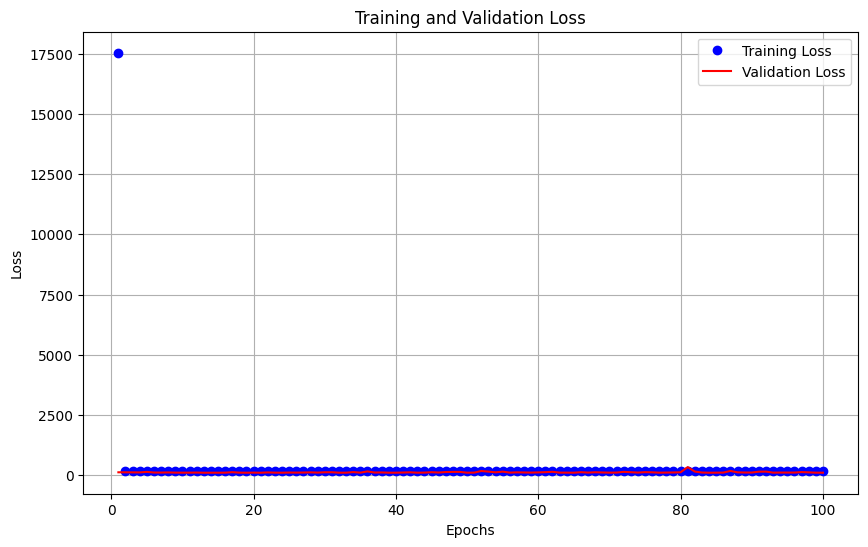

In [ ]:
import matplotlib.pyplot as plt

# Train your model and collect loss values during training
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Extract the loss values from the training history
train_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Create a plot for the training loss and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'bo', label='Training Loss')
plt.plot(epochs, validation_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


Training loss mengukur seberapa baik model Anda mempelajari data pelatihan.
Validation loss mengukur seberapa baik model Anda mampu melakukan generalisasi ke data yang tidak dilihat selama pelatihan.
Idealnya, Anda ingin kedua loss ini rendah dan berkurang seiring bertambahnya epoch, tetapi Anda juga harus berhati-hati terhadap overfitting jika validation loss meningkat.






Tujuan utama adalah untuk memantau validation loss selama pelatihan. Idealnya, Anda ingin melihat bahwa validation loss juga turun seiring dengan training loss, yang menunjukkan bahwa model Anda tidak hanya mempelajari data pelatihan tetapi juga mampu melakukan generalisasi dengan baik.
Jika validation loss mulai meningkat sementara training loss terus menurun, itu bisa menjadi tanda overfitting. Dalam hal ini, Anda mungkin perlu menghentikan pelatihan lebih awal atau menerapkan teknik regularisasi atau dropout untuk mengatasi masalah tersebut.

In [ ]:
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")


1/1 [==============================] - 0s 37ms/step - loss: 957.2766
Test Loss: 957.2765502929688


In [ ]:
# Misalkan Anda sudah memiliki model yang dilatih, dan Anda ingin melakukan prediksi pada data X_test.
y_pred = model.predict(X_test)


1/1 [==============================] - 0s 105ms/step


In [ ]:
data_test=pd.concat([data_series.CH_Keputih[-31:],data_series.prediction[-31:],pd.DataFrame(y_pred)],axis=1)
data_test.head()

,CH_Keputih,prediction,0
0,0.0,7.126569,0.881531
1,14.0,7.098496,0.192720
2,0.0,7.095689,-0.283322
3,2.0,7.095408,0.187353
4,0.0,7.095380,3.332737


In [ ]:
data_test['y_hybrid']= data_test.prediction+data_test.iloc[:,2]
data_test.head()

,CH_Keputih,prediction,0,y_hybrid
0,0.0,7.126569,0.881531,8.008100
1,14.0,7.098496,0.192720,7.291217
2,0.0,7.095689,-0.283322,6.812367
3,2.0,7.095408,0.187353,7.282762
4,0.0,7.095380,3.332737,10.428117


In [ ]:
data_test['y_hybrid_fix'] = data_test['y_hybrid'].apply(lambda x: 0 if x <0  else x)
data_test.head()


,CH_Keputih,prediction,0,y_hybrid,y_hybrid_fix
0,0.0,7.126569,0.881531,8.008100,8.008100
1,14.0,7.098496,0.192720,7.291217,7.291217
2,0.0,7.095689,-0.283322,6.812367,6.812367
3,2.0,7.095408,0.187353,7.282762,7.282762
4,0.0,7.095380,3.332737,10.428117,10.428117


Text(0, 0.5, 'Intensity (mm)')

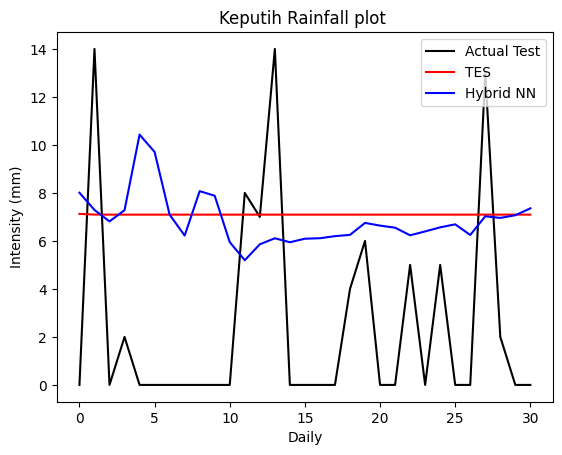

In [ ]:
plt.plot(data_test.iloc[:,0],color='black',label='Actual Test')
plt.plot(data_test.iloc[:,1],color='red',label='TES')
plt.plot(data_test.iloc[:,4],color='blue',label='Hybrid NN')

plt.legend()
plt.title(f'Keputih Rainfall plot ')
plt.xlabel('Daily')
plt.ylabel('Intensity (mm)')

## Code RMSSE

In [ ]:
import numpy as np
from sklearn import metrics

def rmsse(actual_values, forecasted_values):

    actual_values = np.array(actual_values)
    forecasted_values = np.array(forecasted_values)

    n = len(actual_values)

    if n != len(forecasted_values):
        raise ValueError("Input arrays must have the same length.")

    #denominator
    actual_diff = np.diff(actual_values)
    actual_squared_diff = actual_diff ** 2
    mean_actual_squared_diff_test = np.mean(actual_squared_diff)
    RMSE = np.sqrt(metrics.mean_squared_error(actual_values, forecasted_values))
    rmsse= np.sqrt(metrics.mean_squared_error(actual_values, forecasted_values)/mean_actual_squared_diff_test)

    return rmsse


In [ ]:
rmsse(data_test.iloc[:,0],data_test.iloc[:,4])

1.0185420087173842

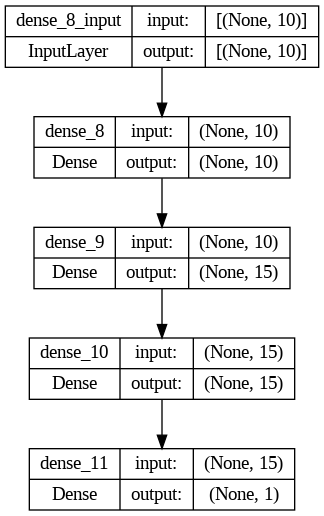

In [ ]:
import pydot
from keras.utils.vis_utils import plot_model

# Define your model as before
model = Sequential([
    Dense(10, activation='relu', input_dim=X_train.shape[1]),  # Input layer
    Dense(15, activation='relu'),
    Dense(15, activation='relu'),  # Hidden layer
    Dense(1)                         # Output layer
])

# Visualize the model and save it to a file (e.g., 'model.png')
plot_model(model, to_file='model.png', show_shapes=True)
